In [1]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import time

In [2]:
df = pd.read_csv('cleaned_autos.csv')
df

,dateCrawled,name,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,lastSeen,car_age,price_in_thousands
0,2016-03-17,GOLF 4 1 4 3TÜRER,test,hatchback,2001,manual,75.0,golf,150.0,6,gasoline,volkswagen,no,2016-03-17,2016-03-17,15.0,1.500000
1,2016-03-31,Skoda Fabia 1.4 TDI PD Classic,test,hatchback,2008,manual,69.0,fabia,90.0,7,diesel,skoda,no,2016-03-31,2016-04-06,8.0,3.600000
2,2016-04-04,BMW 316i e36 Limousine Bastlerfahrzeug Ex...,test,sedan,1995,manual,102.0,3er,150.0,10,gasoline,bmw,yes,2016-04-04,2016-04-06,21.0,0.650000
3,2016-04-01,Peugeot 206 CC 110 Platinum,test,cabrio,2004,manual,109.0,2_reihe,150.0,8,gasoline,peugeot,no,2016-04-01,2016-04-05,12.0,2.200000
4,2016-03-21,VW Derby Bj 80 Scheunenfund,test,sedan,1980,manual,50.0,andere,40.0,7,gasoline,volkswagen,no,2016-03-21,2016-03-25,36.0,6.204583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260738,2016-03-19,turbo defekt,control,sedan,2004,manual,225.0,leon,150.0,5,gasoline,seat,yes,2016-03-19,2016-03-19,12.0,3.200000
260739,2016-03-27,Opel Zafira 1.6 Elegance TÜV 12/16,control,bus,2000,manual,0.0,zafira,150.0,3,gasoline,opel,no,2016-03-27,2016-03-29,16.0,1.150000
260740,2016-03-05,Smart smart leistungssteigerung 100ps,test,cabrio,2000,automatic,101.0,fortwo,125.0,3,gasoline,smart,no,2016-03-05,2016-03-11,16.0,1.199000
260741,2016-03-19,Volkswagen Multivan T4 TDI 7DC UY2,test,bus,1996,manual,102.0,transporter,150.0,3,diesel,volkswagen,no,2016-03-19,2016-04-07,20.0,9.200000


In [3]:
df = df.drop(columns=['dateCrawled', 'dateCreated', 'lastSeen', 'name'])

In [4]:
df['price_class'] = pd.qcut(df['price_in_thousands'], q=3, labels=[ 'Underpriced', 'Fairly Priced', 'Overpriced'])
df

,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,car_age,price_in_thousands,price_class
0,test,hatchback,2001,manual,75.0,golf,150.0,6,gasoline,volkswagen,no,15.0,1.500000,Underpriced
1,test,hatchback,2008,manual,69.0,fabia,90.0,7,diesel,skoda,no,8.0,3.600000,Fairly Priced
2,test,sedan,1995,manual,102.0,3er,150.0,10,gasoline,bmw,yes,21.0,0.650000,Underpriced
3,test,cabrio,2004,manual,109.0,2_reihe,150.0,8,gasoline,peugeot,no,12.0,2.200000,Underpriced
4,test,sedan,1980,manual,50.0,andere,40.0,7,gasoline,volkswagen,no,36.0,6.204583,Fairly Priced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260738,control,sedan,2004,manual,225.0,leon,150.0,5,gasoline,seat,yes,12.0,3.200000,Fairly Priced
260739,control,bus,2000,manual,0.0,zafira,150.0,3,gasoline,opel,no,16.0,1.150000,Underpriced
260740,test,cabrio,2000,automatic,101.0,fortwo,125.0,3,gasoline,smart,no,16.0,1.199000,Underpriced
260741,test,bus,1996,manual,102.0,transporter,150.0,3,diesel,volkswagen,no,20.0,9.200000,Overpriced


In [5]:
x = df.drop(['price_in_thousands', 'price_class'], axis=1)
y = df['price_class']

In [6]:
x = pd.get_dummies(x, drop_first=False)
x

,yearOfRegistration,powerPS,kilometer,monthOfRegistration,car_age,abtest_control,abtest_test,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,...,brand_skoda,brand_smart,brand_subaru,brand_suzuki,brand_toyota,brand_trabant,brand_volkswagen,brand_volvo,notRepairedDamage_no,notRepairedDamage_yes
0,2001,75.0,150.0,6,15.0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,2008,69.0,90.0,7,8.0,False,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,1995,102.0,150.0,10,21.0,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2004,109.0,150.0,8,12.0,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,1980,50.0,40.0,7,36.0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260738,2004,225.0,150.0,5,12.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
260739,2000,0.0,150.0,3,16.0,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
260740,2000,101.0,125.0,3,16.0,False,True,False,True,False,...,False,True,False,False,False,False,False,False,True,False
260741,1996,102.0,150.0,3,20.0,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rt.fit(x_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [8]:
y_pred = rt.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8453469865193963
               precision    recall  f1-score   support

Fairly Priced       0.78      0.77      0.77     17379
   Overpriced       0.90      0.90      0.90     17391
  Underpriced       0.85      0.87      0.86     17379

     accuracy                           0.85     52149
    macro avg       0.85      0.85      0.85     52149
 weighted avg       0.85      0.85      0.85     52149



Text(0.5, 1.0, 'Top 20 Feature Importances')

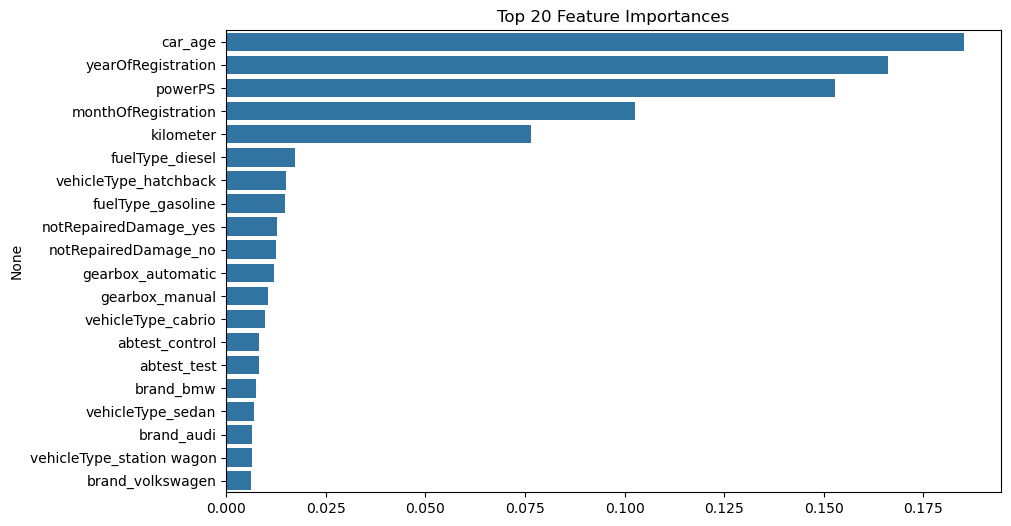

In [9]:
importances = pd.Series(rt.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:20], y=importances.index[:20])
plt.title('Top 20 Feature Importances')

In [10]:
important_features = importances[importances > 0.05].index
print("Selected features:", list(important_features))
x_important = x[important_features]

Selected features: ['car_age', 'yearOfRegistration', 'powerPS', 'monthOfRegistration', 'kilometer']


In [11]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x_important, y, test_size=0.2, random_state=42)

In [12]:
rt2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rt2.fit(x_train2, y_train2)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [13]:
y_pred2 = rt2.predict(x_test2)
print(accuracy_score(y_test2, y_pred2))
print(classification_report(y_test, y_pred))

0.7823544075629446
               precision    recall  f1-score   support

Fairly Priced       0.78      0.77      0.77     17379
   Overpriced       0.90      0.90      0.90     17391
  Underpriced       0.85      0.87      0.86     17379

     accuracy                           0.85     52149
    macro avg       0.85      0.85      0.85     52149
 weighted avg       0.85      0.85      0.85     52149



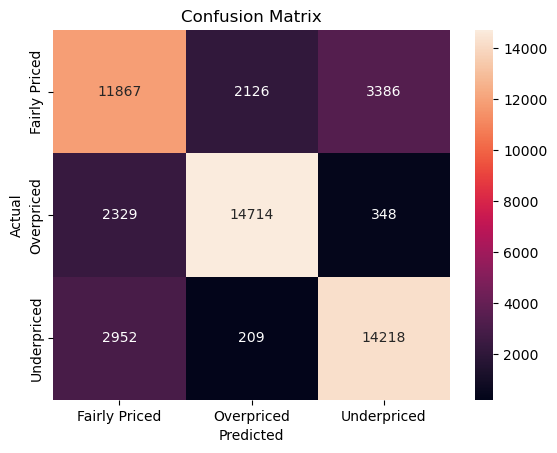

In [14]:
cm = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=rt2.classes_, 
            yticklabels=rt2.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [17]:
rt_pca = RandomForestClassifier(random_state=42)
rt_pca.fit(x_train_pca, y_train)
acc_pca = accuracy_score(y_test, rt_pca.predict(x_test_pca)) * 100

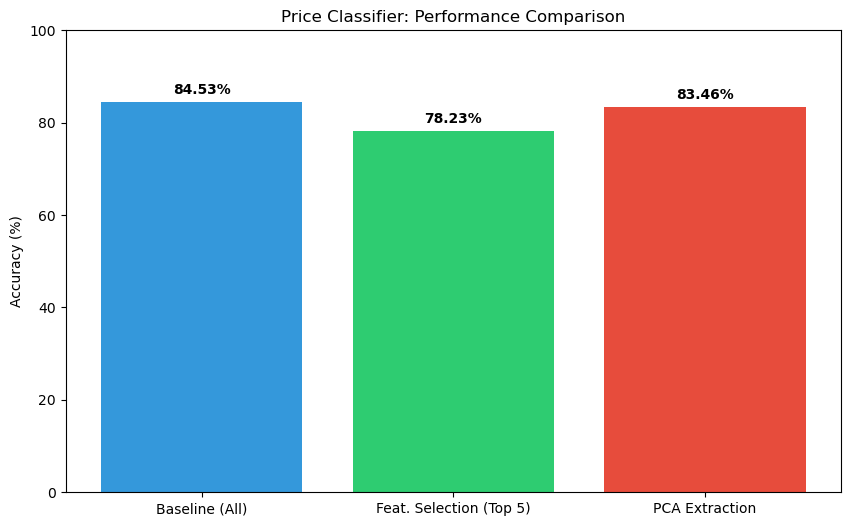

In [18]:
labels = ['Baseline (All)', 'Feat. Selection (Top 5)', 'PCA Extraction']
accuracies = [84.53, 78.23, acc_pca] 

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Price Classifier: Performance Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.show()